# 2D Hyperparameter Grid Search: Alpha, Beta & Gamma Tuning

This notebook performs an exhaustive 2D grid search across:
- **$\alpha \in [0.20, 0.70]$ (Coverability / Information Gain weight)** with fine step `0.02` (and $\beta = 1 - \alpha$)
- **$\gamma \in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]$ (Submodular Overlap / Redundancy factor)**

### The Physical Meaning of the Hyperparameters:
1. **$\alpha$ vs. $\beta$**: Balances exploring new points vs. choosing high-confidence (low-noise) viewpoints.
2. **$\gamma$ (Gamma - Submodular Overlap Factor)**: Controls how much the algorithm values **multi-view angular overlap** vs. pure exploration.
   - $\gamma = 0.00$: **Strict Zero Overlap** (Novel points only).
   - $\gamma = 0.10 - 0.20$: **Complementary Multi-Angle** (Encourages multi-view geometry to constrain 6D ICP).
   - $\gamma \ge 0.30$: **High Redundancy** (Tolerates repeated observations of already mapped surfaces).

For each $(\alpha, \gamma)$ combination, viewpoints are selected for budgets $K \in [1, 2, 3, 4, 8, 12]$, merged from physical scans, and evaluated against OptiTrack ground truth using the **ADD accuracy metric (mm)**.


In [58]:
# ==========================================
# 1. CONFIGURATION & SEARCH SPACE SETUP
# ==========================================
import os
import re
import json
import time
import copy
import glob
import math
import random
import numpy as np
import open3d as o3d
from scipy.spatial.transform import Rotation as R
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Experiment parameters
EXPERIMENT = "test_10_realgrasp"
WORKPIECE = "workpiece31"
CAD_MODEL_DIR = "workpiece31"

# Ground Truth Chamfer Distance noise labels
GT_CSV_PATH = f"processed_data/{EXPERIMENT}/metadata.csv"
if not os.path.exists(GT_CSV_PATH):
    GT_CSV_PATH = f"processed_data/{EXPERIMENT}/{WORKPIECE}/metadata.csv"

WORKPIECE_PATH = f"workpiece/{CAD_MODEL_DIR}/workpiece.stl"
POSES_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}"
GLOBAL_PCD_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}/pcd_all.pcd"
GLOBAL_COVERED_JSON = f"viewpoints_candidate/testing_data/{EXPERIMENT}/covered_indices.json"
REAL_PCD_DIR = f"pcd_data/testing_data/{EXPERIMENT}"
if not os.path.exists(REAL_PCD_DIR):
    REAL_PCD_DIR = f"pcd_data/testing_data/{EXPERIMENT}/{WORKPIECE}"

# 2D Grid Search Space
# ALPHA_VALUES = np.round(np.arange(0.20, 0.72, 0.02), 2).tolist()  # [0.20, 0.22, 0.24, ..., 0.70]
# GAMMA_VALUES = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]                   # Submodular overlap factor
# VIEWPOINT_BUDGETS = [1, 2, 3, 4, 8, 12]

ALPHA_VALUES = [0.55]
GAMMA_VALUES = [0.1]
VIEWPOINT_BUDGETS = [1, 2, 3, 4, 8, 12]


# Registration settings
CROP_BOX = [85, 105, 70]         # [X, Y, Z] extent in mm
NUMBER_OF_POINTS = 40000         # CAD sampling density
ICP_STAGES = [10.0, 5.0, 2.0]    # Coarse-to-fine distance thresholds in mm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    o3d.utility.random.seed(seed)

set_seed(42)
print(f"Configured 2D Grid Search:")
print(f"  - Alpha search space ({len(ALPHA_VALUES)} values): {ALPHA_VALUES}")
print(f"  - Gamma search space ({len(GAMMA_VALUES)} values): {GAMMA_VALUES}")
print(f"  - Viewpoint budgets  : {VIEWPOINT_BUDGETS}")
print(f"  - Total (Alpha, Gamma) combinations: {len(ALPHA_VALUES) * len(GAMMA_VALUES)}")


Configured 2D Grid Search:
  - Alpha search space (1 values): [0.55]
  - Gamma search space (1 values): [0.1]
  - Viewpoint budgets  : [1, 2, 3, 4, 8, 12]
  - Total (Alpha, Gamma) combinations: 1


In [59]:
# ==========================================
# 2. HELPER FUNCTIONS & GEOMETRY PRE-LOADING
# ==========================================
def get_rotation_matrix_z(deg):
    rad = math.radians(deg)
    c, s = math.cos(rad), math.sin(rad)
    return np.array([[c, -s, 0],
                     [s,  c, 0],
                     [0,  0, 1]])

def clean_and_crop_point_cloud(pcd, initial_pos, initial_angle, box_size, remove_plane=True, distance_threshold=3.0, plane_offset=0.5):
    if pcd.is_empty():
        return pcd
    pcd_clean = copy.deepcopy(pcd)
    if remove_plane:
        plane_model, inliers = pcd_clean.segment_plane(distance_threshold=distance_threshold, ransac_n=3, num_iterations=2000)
        [a, b, c, d] = plane_model
        pts = np.asarray(pcd_clean.points)
        distances = a * pts[:, 0] + b * pts[:, 1] + c * pts[:, 2] + d
        above_plane_indices = np.where(distances > plane_offset)[0]
        pcd_clean = pcd_clean.select_by_index(above_plane_indices)
        
    rot_matrix = get_rotation_matrix_z(-initial_angle)
    obb = o3d.geometry.OrientedBoundingBox(
        center=np.array(initial_pos),
        R=rot_matrix,
        extent=np.array(box_size)
    )
    return pcd_clean.crop(obb)

def preprocess_normal(pcd, num_points=False, invert_normals=False, radius=2, max_nn=30):
    if num_points and len(pcd.points) >= num_points:
        pcd_down = pcd.farthest_point_down_sample(num_points)
    else:
        pcd_down = copy.deepcopy(pcd)
    if len(pcd_down.points) == 0:
        return pcd_down, None
    avg_dist = np.mean(pcd_down.compute_nearest_neighbor_distance())
    pcd_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * radius, max_nn=max_nn))
    if invert_normals:
        normals = np.asarray(pcd_down.normals)
        for i in range(len(normals)):
            if normals[i][2] < 0:
                normals[i] *= -1
    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down, o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * 5, max_nn=100)
    )
    return pcd_down, fpfh

def calculate_add(source_cloud, T_est, T_gt):
    points = np.asarray(source_cloud.points)
    ones = np.ones((points.shape[0], 1))
    points_homo = np.hstack([points, ones])
    est_points = (T_est @ points_homo.T).T[:, :3]
    gt_points = (T_gt @ points_homo.T).T[:, :3]
    distances = np.linalg.norm(est_points - gt_points, axis=1)
    return np.mean(distances)

def load_viewpoint_poses_dict(folder_path):
    def extract_number(filename):
        match = re.search(r'viewpoint_pose_(\d+)\.npy', filename)
        return int(match.group(1)) if match else -1
    
    npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    poses = {}
    for f in npy_files:
        idx = extract_number(f)
        if idx != -1:
            poses[idx] = np.load(os.path.join(folder_path, f))
    return poses

# 1. Load CAD Model
mesh = o3d.io.read_triangle_mesh(WORKPIECE_PATH)
mesh.compute_vertex_normals()
cad_cloud = mesh.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)

# 2. Load Global PCD and Visibility Map
pcd_all = o3d.io.read_point_cloud(GLOBAL_PCD_PATH)
import json
with open(GLOBAL_COVERED_JSON, "r") as f:
    global_visibility_dict = json.load(f)
poses_dict = load_viewpoint_poses_dict(POSES_PATH)

# 3. Load OptiTrack Ground Truth Pose (T_average without offset, valid row 4)
optitrack_path = os.path.join(REAL_PCD_DIR, "T_average.npy")
if not os.path.exists(optitrack_path):
    optitrack_path = os.path.join(REAL_PCD_DIR, "T_optitrack.npy")
T_gt = np.load(optitrack_path)
T_gt[3, :] = [0, 0, 0, 1]

if "T_optitrack" in optitrack_path:
    rad_z = math.radians(90.0)
    T_local_rot = np.eye(4)
    T_local_rot[:3, :3] = np.array([
        [math.cos(rad_z), -math.sin(rad_z), 0],
        [math.sin(rad_z),  math.cos(rad_z), 0],
        [0, 0, 1]
    ])
    T_gt = T_gt @ T_local_rot
    T_gt[3, :] = [0, 0, 0, 1]

# 4. Load YOLO Initial Guess
yolo_pose_path = os.path.join(REAL_PCD_DIR, "initial_obj_pose.npy")
if os.path.exists(yolo_pose_path):
    tf_obj = np.load(yolo_pose_path)
    YOLO_POS = tf_obj[:3].copy()
    YOLO_ANGLE = float(tf_obj[4])
    YOLO_POS[0] -= 0
    YOLO_POS[1] -= -10.0
else:
    YOLO_POS = [540.0, -70.0, 20.0]
    YOLO_ANGLE = 0.0

yolo_tf_path = os.path.join(REAL_PCD_DIR, "T_base2ob_yolo.npy")
if os.path.exists(yolo_tf_path):
    T_initial_guess = np.load(yolo_tf_path)
    T_initial_guess[3, :] = [0, 0, 0, 1]
else:
    T_initial_guess = np.eye(4)
    T_initial_guess[:3, :3] = get_rotation_matrix_z(-YOLO_ANGLE)
    T_initial_guess[:3, 3] = YOLO_POS

initial_add = calculate_add(cad_cloud, T_initial_guess, T_gt)
print(f"Loaded CAD Model, Ground Truth Pose, and YOLO Initial Guess.")
print(f"Initial Pose Error before ICP: {initial_add:.4f} mm")


Loaded CAD Model, Ground Truth Pose, and YOLO Initial Guess.
Initial Pose Error before ICP: 16.4454 mm


In [60]:
# ==========================================
# 3. FEATURE SEGMENTATION & SCAN PRE-LOADING
# ==========================================
df_inference = pd.read_csv(GT_CSV_PATH)
df_inference.rename(columns={'filename': 'Filename', 'chamfer_value': 'Predicted_CD'}, inplace=True)
df_inference[['Parsed_Folder', 'Viewpoint', 'Feature']] = df_inference['Filename'].str.extract(r'(.*?)/viewpoint_simulated_(\d+)_(.*?)\.pcd')
df_inference['Viewpoint'] = df_inference['Viewpoint'].astype(int)

df_chamfer = df_inference[df_inference['Parsed_Folder'] == WORKPIECE].copy()
df_chamfer.rename(columns={'Predicted_CD': 'Chamfer_Distance_mm'}, inplace=True)

cad_offset = np.zeros(3)
if os.path.exists(WORKPIECE_PATH) and len(pcd_all.points) > 0:
    wp_mesh = o3d.io.read_triangle_mesh(WORKPIECE_PATH)
    bbox_pcd = pcd_all.get_axis_aligned_bounding_box()
    bbox_mesh = wp_mesh.get_axis_aligned_bounding_box()
    cad_offset = bbox_pcd.get_center() - bbox_mesh.get_center()

features = [f for f in df_chamfer['Feature'].unique() if f != 'background']
feature_indices = {}
all_features_indices = set()
feature_pcds = []
feature_names = []

for feat in features:
    feat_path = f"workpiece/{CAD_MODEL_DIR}/{feat}.stl"
    if not os.path.exists(feat_path):
        alt_feat = feat.replace('feature', 'surface') if 'feature' in feat else feat.replace('surface', 'feature')
        alt_path = f"workpiece/{CAD_MODEL_DIR}/{alt_feat}.stl"
        if os.path.exists(alt_path): feat_path = alt_path
    if os.path.exists(feat_path):
        f_mesh = o3d.io.read_triangle_mesh(feat_path)
        if np.linalg.norm(cad_offset) > 1e-3: f_mesh.translate(cad_offset)
        f_pcd = f_mesh.sample_points_poisson_disk(number_of_points=10000)
        feature_pcds.append(f_pcd)
        feature_names.append(feat)

# Voronoi Nearest-Neighbor Assignment
if len(feature_pcds) > 0 and len(pcd_all.points) > 0:
    dists = np.zeros((len(pcd_all.points), len(feature_pcds)))
    for i, f_pcd in enumerate(feature_pcds):
        dists[:, i] = np.asarray(pcd_all.compute_point_cloud_distance(f_pcd))
    assignments = np.argmin(dists, axis=1)
    for i, feat in enumerate(feature_names):
        idx_set = set(np.where(assignments == i)[0])
        feature_indices[feat] = idx_set
        all_features_indices.update(idx_set)

total_target_points = len(all_features_indices)
print(f"Voronoi segmentation mapped {total_target_points} target points across features: {features}")

# Precompute Static Viewpoint Metadata
static_viewpoint_data = {}
for v_idx, group in df_chamfer.groupby('Viewpoint'):
    v_idx = int(v_idx)
    if v_idx not in poses_dict or pd.isna(group['Chamfer_Distance_mm'].iloc[0]):
        continue
    camera_visible_40k = set(global_visibility_dict.get(str(v_idx), []))
    camera_target_indices = set()
    sum_weighted_chamfer = 0.0
    sum_points = 0
    for _, row in group.iterrows():
        feat = row['Feature']
        chamfer_dist = row['Chamfer_Distance_mm']
        if feat not in feature_indices: continue
        feat_visible_points = camera_visible_40k & feature_indices[feat]
        P_vj = len(feat_visible_points)
        if P_vj == 0: continue
        camera_target_indices.update(feat_visible_points)
        sum_weighted_chamfer += (P_vj * chamfer_dist)
        sum_points += P_vj
    if sum_points == 0: continue
    static_viewpoint_data[v_idx] = {
        'weighted_chamfer': sum_weighted_chamfer / sum_points,
        'visible_target_indices': camera_target_indices,
        'idx_arr': np.array(list(camera_target_indices), dtype=int)
    }

print(f"Precomputed candidate metadata for {len(static_viewpoint_data)} viewpoints.")

# IN-MEMORY CACHING OF PHYSICAL POINT CLOUDS
print("Pre-loading physical PCD files into RAM for instantaneous merging...")
preloaded_scans = {}
for v_idx in static_viewpoint_data.keys():
    for candidate_name in [f"view{v_idx}.pcd", f"view{v_idx:02d}.pcd"]:
        p_path = os.path.join(REAL_PCD_DIR, candidate_name)
        if os.path.exists(p_path):
            raw = o3d.io.read_point_cloud(p_path)
            clean = clean_and_crop_point_cloud(raw, YOLO_POS, YOLO_ANGLE, CROP_BOX, remove_plane=True)
            preloaded_scans[v_idx] = clean
            break

print(f"Successfully cached {len(preloaded_scans)} physical viewpoint scans in memory.")


FileNotFoundError: [Errno 2] No such file or directory: 'processed_data/test_10_realgrasp/workpiece31/metadata.csv'

In [63]:
# ==========================================
# 4. 2D GRID SEARCH EXECUTION ENGINE (ALPHA x GAMMA)
# ==========================================
csv_out_path = f"processed_data/{EXPERIMENT}/alpha_beta_gamma_gridsearch.csv"

def run_greedy_optimization(alpha, beta, gamma, total_steps, static_viewpoint_data, total_points):
    point_coverage_counts = np.zeros(len(pcd_all.points))
    selected_viewpoints = []
    
    for k in range(1, total_steps + 1):
        v_indices = []
        coverabilities = []
        chamfers = []
        
        for v_idx, data in static_viewpoint_data.items():
            if v_idx in selected_viewpoints:
                continue
            idx_arr = data['idx_arr']
            c_vals = point_coverage_counts[idx_arr]
            submodular_sum = np.sum(gamma ** c_vals)
            cov = submodular_sum / total_points
            
            v_indices.append(v_idx)
            coverabilities.append(cov)
            chamfers.append(data['weighted_chamfer'])
            
        if len(v_indices) == 0:
            break
            
        cov_arr = np.array(coverabilities)
        chamfer_arr = np.array(chamfers)
        
        min_cov, max_cov = cov_arr.min(), cov_arr.max()
        norm_cov = (cov_arr - min_cov) / (max_cov - min_cov) if max_cov > min_cov else np.ones_like(cov_arr)
        
        min_c, max_c = chamfer_arr.min(), chamfer_arr.max()
        conf = 1.0 - ((chamfer_arr - min_c) / (max_c - min_c)) if max_c > min_c else np.ones_like(chamfer_arr)
        
        utility = alpha * norm_cov + beta * conf
        best_idx = np.argmax(utility)
        chosen_v_idx = v_indices[best_idx]
        
        selected_viewpoints.append(chosen_v_idx)
        chosen_idx_arr = static_viewpoint_data[chosen_v_idx]['idx_arr']
        point_coverage_counts[chosen_idx_arr] += 1
        
    return selected_viewpoints

icp_cache = {}

def evaluate_icp_pose(viewpoint_subset):
    vp_key = tuple(sorted(viewpoint_subset))
    if vp_key in icp_cache:
        return icp_cache[vp_key]
        
    merged_pcd = o3d.geometry.PointCloud()
    for v_idx in viewpoint_subset:
        if v_idx in preloaded_scans:
            merged_pcd += preloaded_scans[v_idx]
            
    if len(merged_pcd.points) < 50:
        res = {'add_error': 999.0, 'fitness': 0.0, 'rmse': 999.0, 'pts': len(merged_pcd.points)}
        icp_cache[vp_key] = res
        return res
        
    source_transformed = copy.deepcopy(cad_cloud).transform(T_initial_guess)
    source_down, _ = preprocess_normal(source_transformed)
    target_down, _ = preprocess_normal(merged_pcd, invert_normals=True)
    
    current_trans = np.eye(4)
    for thr in ICP_STAGES:
        icp_res = o3d.pipelines.registration.registration_icp(
            source_down, target_down, thr, current_trans,
            o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=300)
        )
        current_trans = icp_res.transformation
        
    T_est = current_trans @ T_initial_guess
    final_add = calculate_add(cad_cloud, T_est, T_gt)
    
    res = {
        'add_error': final_add,
        'fitness': icp_res.fitness,
        'rmse': icp_res.inlier_rmse,
        'pts': len(merged_pcd.points)
    }
    icp_cache[vp_key] = res
    return res

# --------------------------------------------------
# RUN OR LOAD 2D GRID SEARCH RESULTS
# --------------------------------------------------
if os.path.exists(csv_out_path):
    print(f"Found existing Grid Search results at: {csv_out_path}")
    print("Loading precomputed dataset (to re-run from scratch, delete the CSV file).")
    df_grid = pd.read_csv(csv_out_path)
else:
    total_combos = len(ALPHA_VALUES) * len(GAMMA_VALUES)
    print("==================================================")
    print(f"STARTING 2D GRID SEARCH: {len(GAMMA_VALUES)} GAMMAS x {len(ALPHA_VALUES)} ALPHAS ({total_combos} COMBINATIONS)")
    print("==================================================")

    start_time = time.time()
    grid_results = []
    max_budget = max(VIEWPOINT_BUDGETS)
    combo_idx = 0

    for gamma in GAMMA_VALUES:
        for alpha in ALPHA_VALUES:
            combo_idx += 1
            beta = np.round(1.0 - alpha, 2)
            
            seq = run_greedy_optimization(alpha, beta, gamma, max_budget, static_viewpoint_data, total_target_points)
            
            for budget in VIEWPOINT_BUDGETS:
                vp_sub = seq[:budget]
                
                seen_points = set()
                for v in vp_sub:
                    seen_points.update(static_viewpoint_data[v]['visible_target_indices'])
                cum_cov_pct = (len(seen_points) / total_target_points) * 100.0
                
                eval_res = evaluate_icp_pose(vp_sub)
                
                grid_results.append({
                    'Gamma (Overlap)': gamma,
                    'Alpha (Coverage)': alpha,
                    'Beta (Quality)': beta,
                    'Num_Viewpoints': budget,
                    'Selected_Viewpoints': str(vp_sub),
                    'Cumulative_Coverage_%': np.round(cum_cov_pct, 2),
                    'ADD_Error_mm': np.round(eval_res['add_error'], 4),
                    'Fitness': np.round(eval_res['fitness'], 4),
                    'RMSE_mm': np.round(eval_res['rmse'], 4),
                    'Scanned_Points': eval_res['pts']
                })
                
        print(f"[Done Gamma={gamma:4.2f}] Evaluated {len(ALPHA_VALUES)} alpha curves. (Cached unique ICP runs: {len(icp_cache)})")

    df_grid = pd.DataFrame(grid_results)
    os.makedirs(os.path.dirname(csv_out_path), exist_ok=True)
    df_grid.to_csv(csv_out_path, index=False)
    print(f"\n2D GRID SEARCH COMPLETE in {time.time() - start_time:.2f}s! Saved to: {csv_out_path}")


STARTING 2D GRID SEARCH: 1 GAMMAS x 1 ALPHAS (1 COMBINATIONS)
[Done Gamma=0.10] Evaluated 1 alpha curves. (Cached unique ICP runs: 6)

2D GRID SEARCH COMPLETE in 38.08s! Saved to: processed_data/test_10_realgrasp/alpha_beta_gamma_gridsearch.csv


[REPORT] 2D PERFORMANCE TABLE FOR GAMMA = 0.10
   Best Performing Alpha: 0.55 (Beta: 0.45) | Lowest Mean ADD: 2.586 mm

[TABLE 1] Performance by Alpha (Ordered Sequentially from Alpha 0.55 to 0.55):


,Alpha (Coverage),Beta (Quality),1_View_ADD (mm),2_View_ADD (mm),3_View_ADD (mm),4_View_ADD (mm),8_View_ADD (mm),12_View_ADD (mm),Mean_ADD (mm),Best_ADD (mm),Mean_Coverage (%)
#,,,,,,,,,,,
1,0.55,0.45,3.6112,2.8817,2.7374,2.7016,1.951,1.6334,2.586,1.633,72.85



[TABLE 2] Step-by-Step Viewpoint Sequence for Alpha = 0.55 (Beta = 0.45):


,Num_Viewpoints,Selected_Viewpoints,Cumulative_Coverage_%,ADD_Error_mm,Fitness,RMSE_mm
0,1,[226],48.56,3.6112,0.2925,1.1035
1,2,"[226, 137]",76.31,2.8817,0.4218,1.0141
2,3,"[226, 137, 237]",77.50,2.7374,0.4901,0.9764
3,4,"[226, 137, 237, 38]",78.11,2.7016,0.5272,0.9295
4,8,"[226, 137, 237, 38, 239, 165, 273, 155]",78.24,1.9510,0.6428,0.8603
5,12,"[226, 137, 237, 38, 239, 165, 273, 155, 180, 8...",78.38,1.6334,0.7086,0.8196


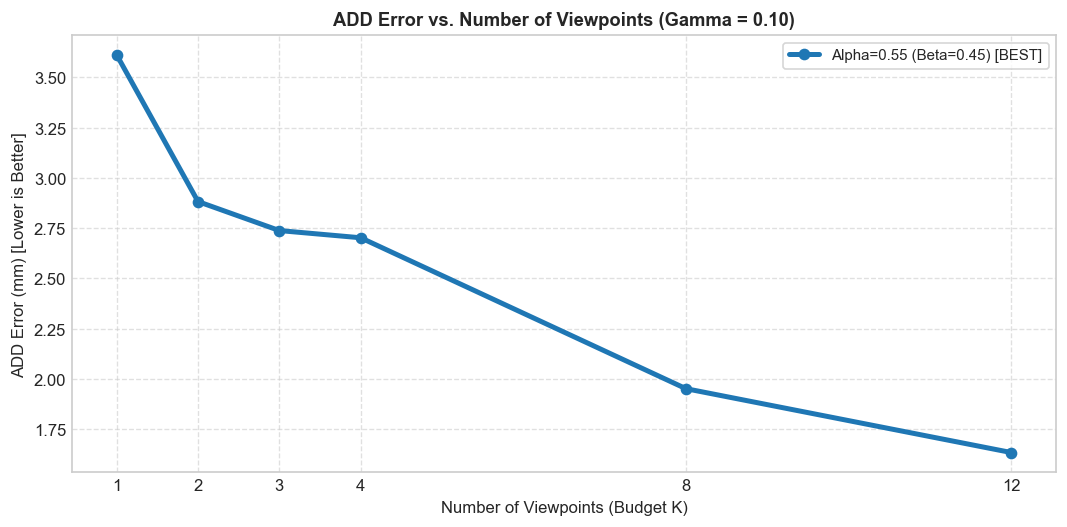

In [64]:
# ==========================================
# 5. DEDICATED 2D TABLE REPORT FOR CERTAIN GAMMA
# ==========================================
def generate_gamma_report(gamma=0.20, alpha=None, show_plot=True):
    """
    Generates a clear 2D Table Report and Convergence Chart for any specific Gamma value.
    Table 1 is ordered sequentially by Alpha value (0.20 -> 0.70).
    
    Parameters:
        gamma (float): Submodular overlap factor (e.g. 0.0, 0.05, 0.1, 0.2, 0.3, 0.5)
        alpha (float, optional): Specific Alpha to inspect in Table 2 (default is best performing Alpha)
        show_plot (bool): Whether to plot ADD convergence curves for this Gamma
    """
    sub_g = df_grid[df_grid['Gamma (Overlap)'] == gamma].copy()
    if sub_g.empty:
        avail_gammas = sorted(df_grid['Gamma (Overlap)'].unique())
        print(f"[ERROR] Gamma = {gamma} not found. Available Gammas: {avail_gammas}")
        return
    
    # 1. Pivot Table: Alpha (rows) vs Viewpoint Budgets (columns)
    piv_add = sub_g.pivot(index=['Alpha (Coverage)', 'Beta (Quality)'], columns='Num_Viewpoints', values='ADD_Error_mm')
    piv_cov = sub_g.pivot(index=['Alpha (Coverage)', 'Beta (Quality)'], columns='Num_Viewpoints', values='Cumulative_Coverage_%')
    
    summary_df = piv_add.copy()
    summary_df.columns = [f"{col}_View_ADD (mm)" for col in summary_df.columns]
    summary_df['Mean_ADD (mm)'] = piv_add.mean(axis=1).round(3)
    summary_df['Best_ADD (mm)'] = piv_add.min(axis=1).round(3)
    summary_df['Mean_Coverage (%)'] = piv_cov.mean(axis=1).round(2)
    summary_df = summary_df.reset_index()
    
    # Find the best performing Alpha for this Gamma
    best_row = summary_df.sort_values(by='Mean_ADD (mm)', ascending=True).iloc[0]
    best_alpha_overall = best_row['Alpha (Coverage)']
    best_beta_overall = best_row['Beta (Quality)']
    best_mean_add = best_row['Mean_ADD (mm)']
    
    # Sort Table 1 sequentially by Alpha value
    summary_df = summary_df.sort_values(by='Alpha (Coverage)', ascending=True).reset_index(drop=True)
    summary_df.index = summary_df.index + 1
    summary_df.index.name = "#"
    
    print("=" * 95)
    print(f"[REPORT] 2D PERFORMANCE TABLE FOR GAMMA = {gamma:.2f}")
    print(f"   Best Performing Alpha: {best_alpha_overall:.2f} (Beta: {best_beta_overall:.2f}) | Lowest Mean ADD: {best_mean_add:.3f} mm")
    print("=" * 95)
    
    print(f"\n[TABLE 1] Performance by Alpha (Ordered Sequentially from Alpha {ALPHA_VALUES[0]} to {ALPHA_VALUES[-1]}):")
    with pd.option_context('display.max_rows', 100, 'display.max_columns', 20):
        display(summary_df)
    
    # Determine which Alpha sequence to show in Table 2
    target_alpha = best_alpha_overall if alpha is None else alpha
    target_beta = np.round(1.0 - target_alpha, 2)
    
    print(f"\n[TABLE 2] Step-by-Step Viewpoint Sequence for Alpha = {target_alpha:.2f} (Beta = {target_beta:.2f}):")
    seq_df = sub_g[sub_g['Alpha (Coverage)'] == target_alpha].sort_values(by='Num_Viewpoints')
    if seq_df.empty:
        print(f"No sequence found for Alpha = {target_alpha}")
    else:
        display(seq_df[['Num_Viewpoints', 'Selected_Viewpoints', 'Cumulative_Coverage_%', 'ADD_Error_mm', 'Fitness', 'RMSE_mm']])
    
    # 3. Optional convergence curve plot
    if show_plot:
        plt.figure(figsize=(9, 4.5), dpi=120)
        # Plot representative alphas across the range (e.g., low, mid, best, high)
        sample_alphas = [0.20, 0.30, 0.40, best_alpha_overall, 0.70]
        sample_alphas = sorted(list(set([a for a in sample_alphas if a in sub_g['Alpha (Coverage)'].values])))
        for a in sample_alphas:
            sub_a = sub_g[sub_g['Alpha (Coverage)'] == a].sort_values(by='Num_Viewpoints')
            b_val = sub_a['Beta (Quality)'].iloc[0]
            lw = 3.0 if a == best_alpha_overall else 1.8
            ls = '-' if a == best_alpha_overall else '--'
            lbl = f"Alpha={a:.2f} (Beta={b_val:.2f}) [BEST]" if a == best_alpha_overall else f"Alpha={a:.2f} (Beta={b_val:.2f})"
            plt.plot(sub_a['Num_Viewpoints'], sub_a['ADD_Error_mm'], marker='o', linewidth=lw, linestyle=ls, label=lbl)
            
        plt.title(f"ADD Error vs. Number of Viewpoints (Gamma = {gamma:.2f})", fontsize=11, fontweight='bold')
        plt.xlabel("Number of Viewpoints (Budget K)", fontsize=10)
        plt.ylabel("ADD Error (mm) [Lower is Better]", fontsize=10)
        plt.xticks(VIEWPOINT_BUDGETS)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(frameon=True, fontsize=9)
        plt.tight_layout()
        plt.show()

# ==========================================
# GENERATE REPORT FOR YOUR CHOSEN GAMMA:
# (Change the value below to 0.0, 0.05, 0.1, 0.2, 0.3, or 0.5)
# ==========================================
generate_gamma_report(gamma=0.1)


In [ ]:
# ==========================================
# 6. SIDE-BY-SIDE MASTER COMPARISON & HEATMAPS
# ==========================================
# Master Comparison Table across all Gammas
master_gamma_rows = []
for g in sorted(df_grid['Gamma (Overlap)'].unique()):
    sub_g = df_grid[df_grid['Gamma (Overlap)'] == g]
    piv = sub_g.pivot(index=['Alpha (Coverage)', 'Beta (Quality)'], columns='Num_Viewpoints', values='ADD_Error_mm')
    piv_cov = sub_g.pivot(index=['Alpha (Coverage)', 'Beta (Quality)'], columns='Num_Viewpoints', values='Cumulative_Coverage_%')
    
    best_idx = piv.mean(axis=1).idxmin()
    best_a, best_b = best_idx[0], best_idx[1]
    
    row_data = {
        'Gamma': g,
        'Best_Alpha': best_a,
        'Best_Beta': best_b,
        'Mean_ADD_mm': np.round(piv.loc[best_idx].mean(), 3),
        '1_View_ADD': np.round(piv.loc[best_idx, 1], 3),
        '2_View_ADD': np.round(piv.loc[best_idx, 2], 3),
        '3_View_ADD': np.round(piv.loc[best_idx, 3], 3),
        '4_View_ADD': np.round(piv.loc[best_idx, 4], 3),
        '8_View_ADD': np.round(piv.loc[best_idx, 8], 3),
        '12_View_ADD': np.round(piv.loc[best_idx, 12], 3),
        'Mean_Coverage_%': np.round(piv_cov.loc[best_idx].mean(), 2)
    }
    master_gamma_rows.append(row_data)

df_master = pd.DataFrame(master_gamma_rows).sort_values(by='Mean_ADD_mm').reset_index(drop=True)
df_master.index = df_master.index + 1
df_master.index.name = "Rank"

print("=========================================================================================")
print("MASTER SIDE-BY-SIDE COMPARISON ACROSS ALL GAMMA VALUES (BEST CONFIGURATION FOR EACH)")
print("=========================================================================================")
display(df_master)

# Visualizations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=120)

# Plot 1: 4-View ADD vs Alpha across Gammas
ax1 = axes[0]
df_4v = df_grid[df_grid['Num_Viewpoints'] == 4]
for g in GAMMA_VALUES:
    sub_g = df_4v[df_4v['Gamma (Overlap)'] == g]
    ax1.plot(sub_g['Alpha (Coverage)'], sub_g['ADD_Error_mm'], marker='o', linewidth=2, label=f"Gamma = {g}")
ax1.set_title("4-Viewpoint Accuracy: ADD Error vs. Alpha", fontsize=12, fontweight='bold')
ax1.set_xlabel("Alpha (Coverability Weight)", fontsize=10)
ax1.set_ylabel("ADD Error (mm) [Lower is Better]", fontsize=10)
ax1.legend(frameon=True, fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: 12-View ADD vs Alpha across Gammas
ax2 = axes[1]
df_12v = df_grid[df_grid['Num_Viewpoints'] == 12]
for g in GAMMA_VALUES:
    sub_g = df_12v[df_12v['Gamma (Overlap)'] == g]
    ax2.plot(sub_g['Alpha (Coverage)'], sub_g['ADD_Error_mm'], marker='s', linewidth=2, label=f"Gamma = {g}")
ax2.set_title("12-Viewpoint Accuracy: ADD Error vs. Alpha", fontsize=12, fontweight='bold')
ax2.set_xlabel("Alpha (Coverability Weight)", fontsize=10)
ax2.set_ylabel("ADD Error (mm) [Lower is Better]", fontsize=10)
ax2.legend(frameon=True, fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: 2D Heatmap of Mean ADD Error across Gamma and Alpha
ax3 = axes[2]
leaderboard = df_grid.groupby(['Gamma (Overlap)', 'Alpha (Coverage)'])['ADD_Error_mm'].mean().reset_index()
pivot_mean = leaderboard.pivot(index='Gamma (Overlap)', columns='Alpha (Coverage)', values='ADD_Error_mm')
sns.heatmap(pivot_mean, cmap="YlGnBu_r", annot=False, cbar_kws={'label': 'Mean ADD Error (mm)'}, ax=ax3)
ax3.set_title("2D Heatmap: Mean ADD Error (Gamma vs. Alpha)", fontsize=12, fontweight='bold')
ax3.set_xlabel("Alpha (Coverability Weight)", fontsize=10)
ax3.set_ylabel("Gamma (Overlap Factor)", fontsize=10)

plt.tight_layout()
plt.savefig(f"processed_data/{EXPERIMENT}/alpha_gamma_gridsearch_plots.png", dpi=300)
plt.show()
